<a href="https://colab.research.google.com/github/kalyankargouri/Deep-Learning/blob/main/DLexper2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt


In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values (0 to 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten 28x28 → 784
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9146 - loss: 0.3019 - val_accuracy: 0.9573 - val_loss: 0.1444
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9654 - loss: 0.1140 - val_accuracy: 0.9645 - val_loss: 0.1142
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9770 - loss: 0.0744 - val_accuracy: 0.9707 - val_loss: 0.0970
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9841 - loss: 0.0531 - val_accuracy: 0.9738 - val_loss: 0.0925
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9884 - loss: 0.0373 - val_accuracy: 0.9758 - val_loss: 0.0918
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0293 - val_accuracy: 0.9758 - val_loss: 0.0886
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9931 - loss: 0.0215 - val_accuracy: 0.9777 - val_loss: 0.0857
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9947 - loss: 0.0171 - val_accuracy:

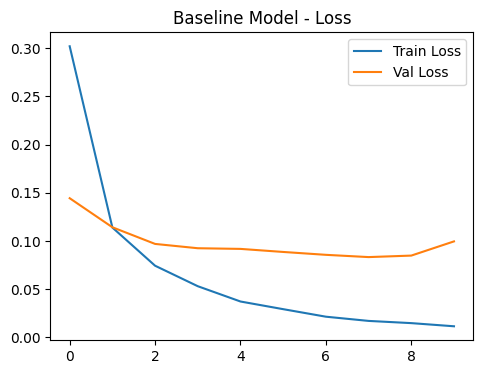

In [4]:
baseline_model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

baseline_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

history_baseline = baseline_model.fit(X_train, y_train,
                                      validation_split=0.2,
                                      epochs=10,
                                      batch_size=128,
                                      verbose=1)

plot_history(history_baseline, "Baseline Model")


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8221 - loss: 0.5762 - val_accuracy: 0.9434 - val_loss: 0.1909
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9237 - loss: 0.2655 - val_accuracy: 0.9617 - val_loss: 0.1390
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9400 - loss: 0.2052 - val_accuracy: 0.9662 - val_loss: 0.1195
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9486 - loss: 0.1758 - val_accuracy: 0.9694 - val_loss: 0.1065
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9544 - loss: 0.1558 - val_accuracy: 0.9722 - val_loss: 0.0979
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9581 - loss: 0.1439 - val_accuracy: 0.9719 - val_loss: 0.0961
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9620 - loss: 0.1301 - val_accuracy: 0.9733 - val_loss: 0.0939
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9659 - loss: 0.1178 - val_accuracy: 0

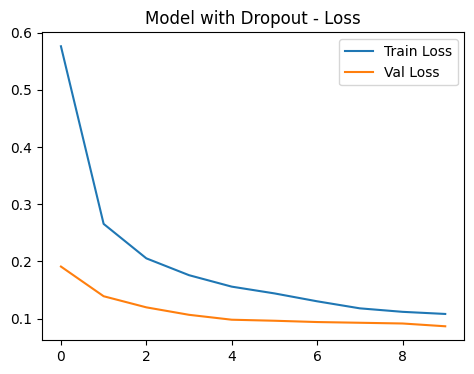

In [6]:
dropout_model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

dropout_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history_dropout = dropout_model.fit(X_train, y_train,
                                    validation_split=0.2,
                                    epochs=10,
                                    batch_size=128,
                                    verbose=1)

plot_history(history_dropout, "Model with Dropout")


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9101 - loss: 0.6247 - val_accuracy: 0.9543 - val_loss: 0.3892
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9581 - loss: 0.3407 - val_accuracy: 0.9605 - val_loss: 0.3029
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9663 - loss: 0.2667 - val_accuracy: 0.9657 - val_loss: 0.2521
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9713 - loss: 0.2250 - val_accuracy: 0.9707 - val_loss: 0.2206
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9738 - loss: 0.2024 - val_accuracy: 0.9721 - val_loss: 0.2038
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9750 - loss: 0.1884 - val_accuracy: 0.9718 - val_loss: 0.1987
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9777 - loss: 0.1754 - val_accuracy: 0.9687 - val_loss: 0.1966
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9782 - loss: 0.1669 - val_accuracy:

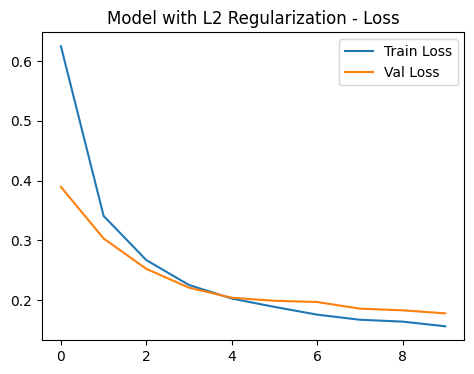

In [7]:
l2_model = Sequential([
    Dense(256, activation='relu', kernel_regularizer=l2(0.001), input_shape=(784,)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(10, activation='softmax')
])

l2_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_l2 = l2_model.fit(X_train, y_train,
                          validation_split=0.2,
                          epochs=10,
                          batch_size=128,
                          verbose=1)

plot_history(history_l2, "Model with L2 Regularization")


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9330 - loss: 0.2270 - val_accuracy: 0.9654 - val_loss: 0.1229
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9752 - loss: 0.0838 - val_accuracy: 0.9695 - val_loss: 0.0990
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9839 - loss: 0.0532 - val_accuracy: 0.9747 - val_loss: 0.0861
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9882 - loss: 0.0385 - val_accuracy: 0.9739 - val_loss: 0.0887
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0297 - val_accuracy: 0.9766 - val_loss: 0.0843
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9930 - loss: 0.0226 - val_accuracy: 0.9730 - val_loss: 0.1000
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9941 - loss: 0.0192 - val_accuracy: 0.9751 - val_loss: 0.0893
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9961 - loss: 0.0133 - val_accuracy: 

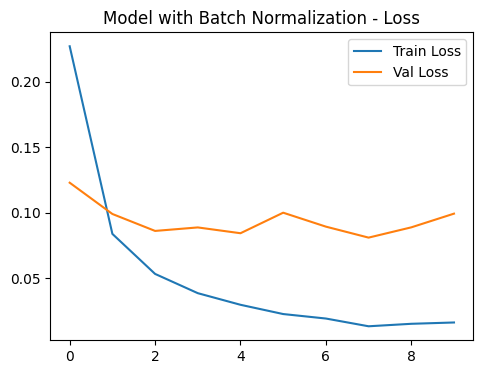

In [8]:
bn_model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

bn_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_bn = bn_model.fit(X_train, y_train,
                          validation_split=0.2,
                          epochs=10,
                          batch_size=128,
                          verbose=1)

plot_history(history_bn, "Model with Batch Normalization")
